# Experiment 3: Fine-tune four RUGD-trained models on RELLIS-3D

This notebook fine-tunes four RUGD-trained binary ground/non-ground segmentation models on RELLIS-3D:

- U-Net
- DeepLabV3+
- SegFormer-B0
- ROD (EfficientSAM-S encoder + ROD segmentation decoder)

Experiment:

**RUGD checkpoint → RELLIS-3D fine-tuning → RELLIS-3D test**

Training loss for **all four models** is:

`CrossEntropyLoss(ignore_index=255)`

Dice remains an evaluation metric only and does not participate in optimisation.

ROD retains its architecture-specific input pipeline:
- aspect-ratio-preserving resize and padding to `512 × 512`;
- ImageNet-equivalent ROD normalization in the original 0–255 pixel scale;
- EfficientSAM internal input size `1024 × 1024`;
- EfficientSAM encoder frozen during fine-tuning.

All outputs are written directly to:

`/content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d`

In [1]:
!pip -q install segmentation-models-pytorch timm

import os
import sys

ROD_REPO = "/content/offroad_roadseg"

if not os.path.exists(ROD_REPO):
    !git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git {ROD_REPO}

if ROD_REPO not in sys.path:
    sys.path.insert(0, ROD_REPO)

print("ROD repository:", ROD_REPO)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
Cloning into '/content/offroad_roadseg'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 80 (delta 17), reused 78 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.32 MiB | 21.28 MiB/s, done.
Resolving deltas: 100% (17/17), done.
ROD repository: /content/offroad_roadseg


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration

In [6]:
from pathlib import Path

DATASET_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/processed/RELLIS_3D_binary_processed.zip"
)

CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "unet_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "segformer_b0_rugd_binary_ground_best_20epochs.pth"
    ),
    "ROD": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "rod_rugd_binary_ground_best_20epochs.pth"
    ),
}

LOCAL_DATA_ROOT = Path(
    "/content/rellis_finetune_data"
)

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d"
)

EXP2_CSV_CANDIDATES = [
    Path(
        "/content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_rellis3d/"
        "model_summary.csv"
    ),
    Path(
        "/content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_rellis3d/"
        "rugd_checkpoints_on_rellis3d_summary.csv"
    ),
]

NON_GROUND_CLASS = 0
GROUND_CLASS = 1
IGNORE_INDEX = 255
NUM_CLASSES = 2

INPUT_SIZE = (512, 512)
BATCH_SIZE = 8
ROD_BATCH_SIZE = 1
NUM_WORKERS = 2
PIN_MEMORY = True

EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5
RANDOM_SEED = 42

MODEL_CONFIGS = {
    "U-Net": {
        "input_size": INPUT_SIZE,
        "normalization": "imagenet",
        "encoder_name": "resnet34",
        "preprocess_mode": "direct_resize",
    },
    "DeepLabV3+": {
        "input_size": INPUT_SIZE,
        "normalization": "imagenet",
        "encoder_name": "resnet34",
        "encoder_output_stride": 16,
        "preprocess_mode": "direct_resize",
    },
    "SegFormer-B0": {
        "input_size": INPUT_SIZE,
        "normalization": "imagenet",
        "encoder_name": "mit_b0",
        "preprocess_mode": "direct_resize",
    },
    "ROD": {
        "input_size": INPUT_SIZE,
        "normalization": "rod_imagenet_255",
        "encoder_name": "EfficientSAM-S",
        "preprocess_mode": "aspect_ratio_pad",
        "encoder_input_size": (1024, 1024),
        "freeze_encoder": True,
    },
}

MODEL_DISPLAY_ORDER = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]

print("Dataset ZIP:", DATASET_ZIP)
for model_name, path in CHECKPOINTS.items():
    print(f"{model_name}: {path}")
print("Results:", RESULTS_ROOT)

Dataset ZIP: /content/drive/MyDrive/IRP/01_data/processed/RELLIS_3D_binary_processed.zip
U-Net: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
DeepLabV3+: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
SegFormer-B0: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth
ROD: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth
Results: /content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d


## 2. Extract and validate the processed RELLIS-3D dataset

In [7]:
import os
import random
import shutil
import zipfile
import json
import time
from collections import defaultdict, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import segmentation_models_pytorch as smp


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(RANDOM_SEED)

if not DATASET_ZIP.exists():
    raise FileNotFoundError(
        f"Dataset ZIP not found: {DATASET_ZIP}"
    )

missing_checkpoints = [
    (name, path)
    for name, path in CHECKPOINTS.items()
    if not path.exists()
]

if missing_checkpoints:
    print("Missing checkpoints:")
    for name, path in missing_checkpoints:
        print(f"  {name}: {path}")
    raise FileNotFoundError(
        "One or more RUGD checkpoint paths are incorrect."
    )

extract_marker = (
    LOCAL_DATA_ROOT
    / ".extract_complete"
)

if not extract_marker.exists():
    if LOCAL_DATA_ROOT.exists():
        shutil.rmtree(
            LOCAL_DATA_ROOT
        )

    LOCAL_DATA_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        f"Extracting {DATASET_ZIP.name} "
        f"to {LOCAL_DATA_ROOT} ..."
    )

    with zipfile.ZipFile(
        DATASET_ZIP,
        "r",
    ) as zf:
        zf.extractall(
            LOCAL_DATA_ROOT
        )

    extract_marker.touch()
    print("Extraction completed.")
else:
    print(
        "Dataset already extracted "
        "in this Colab session."
    )

RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

Extracting RELLIS_3D_binary_processed.zip to /content/rellis_finetune_data ...
Extraction completed.


In [8]:
def find_processed_root(search_root: Path) -> Path:
    """Find RELLIS_3D_binary_processed root created by your preprocessing notebook."""
    candidates = [search_root] + [p for p in search_root.rglob('*') if p.is_dir()]
    for candidate in candidates:
        required = [
            candidate / 'images' / 'train',
            candidate / 'images' / 'val',
            candidate / 'images' / 'test',
            candidate / 'masks' / 'train',
            candidate / 'masks' / 'val',
            candidate / 'masks' / 'test',
        ]
        if all(p.is_dir() for p in required):
            return candidate
    raise FileNotFoundError(
        'Could not find processed dataset root with images/{train,val,test} '
        'and masks/{train,val,test} inside the extracted ZIP.'
    )

DATA_ROOT = find_processed_root(LOCAL_DATA_ROOT)
print('Processed dataset root:', DATA_ROOT)

for split in ['train', 'val', 'test']:
    print(f'{split:5s} images:', DATA_ROOT / 'images' / split)
    print(f'{split:5s} masks: ', DATA_ROOT / 'masks' / split)

manifest_path = DATA_ROOT / 'manifest.csv'
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path)
    print('\nManifest rows:', len(manifest))
    display(manifest.head())
else:
    manifest = None
    print('\nNo manifest.csv found. The notebook will match files by relative path/stem.')

mapping_path = DATA_ROOT / 'binary_label_mapping.csv'
if mapping_path.exists():
    mapping_table = pd.read_csv(mapping_path)
    print('\nBinary label mapping from preprocessing notebook:')
    display(mapping_table)

Processed dataset root: /content/rellis_finetune_data/RELLIS_3D_binary_processed
train images: /content/rellis_finetune_data/RELLIS_3D_binary_processed/images/train
train masks:  /content/rellis_finetune_data/RELLIS_3D_binary_processed/masks/train
val   images: /content/rellis_finetune_data/RELLIS_3D_binary_processed/images/val
val   masks:  /content/rellis_finetune_data/RELLIS_3D_binary_processed/masks/val
test  images: /content/rellis_finetune_data/RELLIS_3D_binary_processed/images/test
test  masks:  /content/rellis_finetune_data/RELLIS_3D_binary_processed/masks/test

Manifest rows: 6234


,split,sequence,source_image,source_mask,processed_image,processed_mask
0,train,0,Rellis-3D/00000/pylon_camera_node/frame000000-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...
1,train,0,Rellis-3D/00000/pylon_camera_node/frame000002-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...
2,train,0,Rellis-3D/00000/pylon_camera_node/frame000004-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...
3,train,0,Rellis-3D/00000/pylon_camera_node/frame000006-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...
4,train,0,Rellis-3D/00000/pylon_camera_node/frame000008-...,Rellis-3D/00000/pylon_camera_node_label_color/...,images/train/Rellis-3D__00000__pylon_camera_no...,masks/train/Rellis-3D__00000__pylon_camera_nod...



Binary label mapping from preprocessing notebook:


,original_id,class_name,rgb,binary_id,binary_class
0,0,void,"(0, 0, 0)",255,ignore
1,1,dirt,"(108, 64, 20)",1,ground
2,3,grass,"(0, 102, 0)",1,ground
3,4,tree,"(0, 255, 0)",0,non-ground
4,5,pole,"(0, 153, 153)",0,non-ground
5,6,water,"(0, 128, 255)",0,non-ground
6,7,sky,"(0, 0, 255)",255,ignore
7,8,vehicle,"(255, 255, 0)",0,non-ground
8,9,object,"(255, 0, 127)",0,non-ground
9,10,asphalt,"(64, 64, 64)",1,ground


## 3. Match image and mask pairs for train / val / test

In [9]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}


def list_images(root: Path):
    return sorted(
        p for p in root.rglob('*')
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def relative_stem(path: Path, root: Path) -> str:
    relative = path.relative_to(root)
    return str(relative.with_suffix('')).replace('\\', '/')


def collect_pairs_for_split(data_root: Path, split: str):
    image_root = data_root / 'images' / split
    mask_root = data_root / 'masks' / split

    image_paths = list_images(image_root)
    mask_paths = list_images(mask_root)

    mask_index = defaultdict(list)
    for mask_path in mask_paths:
        mask_index[relative_stem(mask_path, mask_root)].append(mask_path)

    pairs = []
    missing = []
    ambiguous = []
    for image_path in image_paths:
        key = relative_stem(image_path, image_root)
        candidates = mask_index.get(key, [])
        if len(candidates) == 1:
            pairs.append((image_path, candidates[0]))
        elif len(candidates) == 0:
            missing.append(image_path)
        else:
            ambiguous.append((image_path, candidates))

    print(f'\n{split.upper()}')
    print('Images found:', len(image_paths))
    print('Masks found: ', len(mask_paths))
    print('Matched pairs:', len(pairs))
    print('Missing masks:', len(missing))
    print('Ambiguous matches:', len(ambiguous))

    if missing:
        print('First missing masks:')
        for path in missing[:5]:
            print(' ', path.relative_to(image_root))
    if ambiguous:
        raise RuntimeError(f'Ambiguous matches found in split {split}. Inspect directory structure.')
    if not pairs:
        raise RuntimeError(f'No image-mask pairs found for split {split}.')
    return pairs

split_pairs = {
    split: collect_pairs_for_split(DATA_ROOT, split)
    for split in ['train', 'val', 'test']
}


TRAIN
Images found: 4435
Masks found:  4435
Matched pairs: 4435
Missing masks: 0
Ambiguous matches: 0

VAL
Images found: 900
Masks found:  900
Matched pairs: 900
Missing masks: 0
Ambiguous matches: 0

TEST
Images found: 899
Masks found:  899
Matched pairs: 899
Missing masks: 0
Ambiguous matches: 0


## 4. Dataset and transforms

In [10]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]

ROD_PIXEL_MEAN = np.array(
    [123.675, 116.28, 103.53],
    dtype=np.float32,
)

ROD_PIXEL_STD = np.array(
    [58.395, 57.12, 57.375],
    dtype=np.float32,
)

EXPECTED_MASK_VALUES = {
    NON_GROUND_CLASS,
    GROUND_CLASS,
    IGNORE_INDEX,
}


class RELLISBinaryDataset(Dataset):
    def __init__(
        self,
        pairs,
        input_size=(512, 512),
        split="train",
        augment=False,
    ):
        self.pairs = list(pairs)
        self.input_size = tuple(
            input_size
        )
        self.split = split
        self.augment = augment

    def __len__(self):
        return len(
            self.pairs
        )

    def _augment(
        self,
        image,
        mask,
    ):
        if random.random() < 0.5:
            image = TF.hflip(
                image
            )
            mask = TF.hflip(
                mask
            )

        if random.random() < 0.5:
            image = TF.adjust_brightness(
                image,
                1.0
                + random.uniform(
                    -0.2,
                    0.2,
                ),
            )

        if random.random() < 0.5:
            image = TF.adjust_contrast(
                image,
                1.0
                + random.uniform(
                    -0.2,
                    0.2,
                ),
            )

        if random.random() < 0.3:
            image = TF.adjust_saturation(
                image,
                1.0
                + random.uniform(
                    -0.15,
                    0.15,
                ),
            )

        return (
            image,
            mask,
        )

    def __getitem__(
        self,
        index,
    ):
        image_path, mask_path = (
            self.pairs[
                index
            ]
        )

        image = Image.open(
            image_path
        ).convert(
            "RGB"
        )

        mask = Image.open(
            mask_path
        ).convert(
            "L"
        )

        if self.augment:
            image, mask = (
                self._augment(
                    image,
                    mask,
                )
            )

        image = TF.resize(
            image,
            self.input_size,
            interpolation=(
                InterpolationMode.BILINEAR
            ),
            antialias=True,
        )

        mask = TF.resize(
            mask,
            self.input_size,
            interpolation=(
                InterpolationMode.NEAREST
            ),
        )

        image = TF.to_tensor(
            image
        )

        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

        mask = torch.from_numpy(
            np.array(
                mask,
                dtype=np.uint8,
            )
        ).long()

        values = set(
            torch.unique(
                mask
            ).tolist()
        )

        if not values.issubset(
            EXPECTED_MASK_VALUES
        ):
            raise ValueError(
                f"Unexpected mask values "
                f"{values} in {mask_path}."
            )

        return {
            "image": image,
            "mask": mask,
            "image_path": str(
                image_path
            ),
            "mask_path": str(
                mask_path
            ),
        }


def rod_resize_pad_pair(
    image_np,
    mask_np,
    size=512,
):
    h, w = image_np.shape[:2]

    scale = (
        size
        / max(h, w)
    )

    new_h = int(
        round(
            h * scale
        )
    )

    new_w = int(
        round(
            w * scale
        )
    )

    image_resized = np.array(
        Image.fromarray(
            image_np
        ).resize(
            (
                new_w,
                new_h,
            ),
            resample=(
                Image.Resampling.BILINEAR
            ),
        )
    )

    mask_resized = np.array(
        Image.fromarray(
            mask_np
        ).resize(
            (
                new_w,
                new_h,
            ),
            resample=(
                Image.Resampling.NEAREST
            ),
        ),
        dtype=np.uint8,
    )

    image_canvas = np.zeros(
        (
            size,
            size,
            3,
        ),
        dtype=np.uint8,
    )

    mask_canvas = np.full(
        (
            size,
            size,
        ),
        IGNORE_INDEX,
        dtype=np.uint8,
    )

    top = (
        size - new_h
    ) // 2

    left = (
        size - new_w
    ) // 2

    image_canvas[
        top:top + new_h,
        left:left + new_w,
    ] = image_resized

    mask_canvas[
        top:top + new_h,
        left:left + new_w,
    ] = mask_resized

    return (
        image_canvas,
        mask_canvas,
    )


class RELLISRODDataset(Dataset):
    def __init__(
        self,
        pairs,
        split="train",
        augment=False,
    ):
        self.pairs = list(
            pairs
        )
        self.split = split
        self.augment = augment

    def __len__(
        self
    ):
        return len(
            self.pairs
        )

    def __getitem__(
        self,
        index,
    ):
        image_path, mask_path = (
            self.pairs[
                index
            ]
        )

        image = Image.open(
            image_path
        ).convert(
            "RGB"
        )

        mask = Image.open(
            mask_path
        ).convert(
            "L"
        )

        if self.augment:
            if random.random() < 0.5:
                image = TF.hflip(
                    image
                )
                mask = TF.hflip(
                    mask
                )

            if random.random() < 0.5:
                image = TF.adjust_brightness(
                    image,
                    1.0
                    + random.uniform(
                        -0.2,
                        0.2,
                    ),
                )

            if random.random() < 0.5:
                image = TF.adjust_contrast(
                    image,
                    1.0
                    + random.uniform(
                        -0.2,
                        0.2,
                    ),
                )

            if random.random() < 0.3:
                image = TF.adjust_saturation(
                    image,
                    1.0
                    + random.uniform(
                        -0.15,
                        0.15,
                    ),
                )

        image_np = np.array(
            image,
            dtype=np.uint8,
        )

        mask_np = np.array(
            mask,
            dtype=np.uint8,
        )

        (
            image_np,
            mask_np,
        ) = rod_resize_pad_pair(
            image_np,
            mask_np,
            size=INPUT_SIZE[0],
        )

        image_np = (
            image_np.astype(
                np.float32
            )
            - ROD_PIXEL_MEAN
        ) / ROD_PIXEL_STD

        image_tensor = (
            torch.from_numpy(
                image_np
            )
            .permute(
                2,
                0,
                1,
            )
            .contiguous()
        )

        mask_tensor = (
            torch.from_numpy(
                mask_np
            )
            .long()
        )

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_path": str(
                image_path
            ),
            "mask_path": str(
                mask_path
            ),
        }


def build_loader(
    split,
    batch_size=BATCH_SIZE,
    shuffle=None,
    model_name="U-Net",
):
    if shuffle is None:
        shuffle = (
            split
            == "train"
        )

    if model_name == "ROD":
        dataset = RELLISRODDataset(
            pairs=split_pairs[
                split
            ],
            split=split,
            augment=(
                split
                == "train"
            ),
        )

        batch_size = (
            ROD_BATCH_SIZE
        )

    else:
        dataset = RELLISBinaryDataset(
            pairs=split_pairs[
                split
            ],
            input_size=INPUT_SIZE,
            split=split,
            augment=(
                split
                == "train"
            ),
        )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )

    return (
        dataset,
        loader,
    )


train_dataset, train_loader = (
    build_loader(
        "train"
    )
)

val_dataset, val_loader = (
    build_loader(
        "val",
        shuffle=False,
    )
)

test_dataset, test_loader = (
    build_loader(
        "test",
        shuffle=False,
    )
)

rod_train_dataset, rod_train_loader = (
    build_loader(
        "train",
        model_name="ROD",
    )
)

rod_val_dataset, rod_val_loader = (
    build_loader(
        "val",
        shuffle=False,
        model_name="ROD",
    )
)

rod_test_dataset, rod_test_loader = (
    build_loader(
        "test",
        shuffle=False,
        model_name="ROD",
    )
)


def get_model_data(
    model_name,
):
    if model_name == "ROD":
        return (
            rod_train_dataset,
            rod_val_dataset,
            rod_test_dataset,
            rod_train_loader,
            rod_val_loader,
            rod_test_loader,
        )

    return (
        train_dataset,
        val_dataset,
        test_dataset,
        train_loader,
        val_loader,
        test_loader,
    )


print(
    "Baseline train samples:",
    len(train_dataset),
)

print(
    "ROD train samples:",
    len(rod_train_dataset),
)

print(
    "Baseline batch:",
    next(
        iter(
            train_loader
        )
    )["image"].shape,
)

print(
    "ROD batch:",
    next(
        iter(
            rod_train_loader
        )
    )["image"].shape,
)

Baseline train samples: 4435
ROD train samples: 4435
Baseline batch: torch.Size([8, 3, 512, 512])
ROD batch: torch.Size([1, 3, 512, 512])


In [11]:
def denormalize(
    image_tensor,
    model_name="U-Net",
):
    image = (
        image_tensor
        .detach()
        .cpu()
    )

    if model_name == "ROD":
        image = (
            image.permute(
                1,
                2,
                0,
            )
            .numpy()
        )

        image = (
            image
            * ROD_PIXEL_STD
            + ROD_PIXEL_MEAN
        )

        return np.clip(
            image / 255.0,
            0,
            1,
        )

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(
        3,
        1,
        1,
    )

    std = torch.tensor(
        IMAGENET_STD
    ).view(
        3,
        1,
        1,
    )

    image = (
        image
        * std
        + mean
    )

    return (
        image
        .clamp(
            0,
            1,
        )
        .permute(
            1,
            2,
            0,
        )
        .numpy()
    )

## 5. Model definitions and robust checkpoint loading

In [12]:
import os
import shutil
import zipfile

WEIGHTS_DIR = (
    Path(ROD_REPO)
    / "efficient_sam"
    / "weights"
)

WEIGHTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

WEIGHTS_ZIP = (
    WEIGHTS_DIR
    / "efficient_sam_vits.pt.zip"
)

VITS_PATH = (
    WEIGHTS_DIR
    / "efficient_sam_vits.pt"
)

if not VITS_PATH.exists():
    if not WEIGHTS_ZIP.exists():
        !wget -q --show-progress https://github.com/yformer/EfficientSAM/raw/main/weights/efficient_sam_vits.pt.zip -O {WEIGHTS_ZIP}

    with zipfile.ZipFile(
        WEIGHTS_ZIP,
        "r",
    ) as archive:
        archive.extractall(
            WEIGHTS_DIR
        )

from efficient_sam.build_efficient_sam import (
    build_efficient_sam_vits,
)

from seg_decoder import SegHead


def load_rod_encoder(
    checkpoint_path,
):
    checkpoint_path = (
        Path(
            checkpoint_path
        ).resolve()
    )

    efficient_sam_dir = (
        Path(
            ROD_REPO
        )
        / "efficient_sam"
    )

    expected_checkpoint = (
        efficient_sam_dir
        / "weights"
        / "efficient_sam_vits.pt"
    ).resolve()

    if (
        checkpoint_path
        != expected_checkpoint
    ):
        expected_checkpoint.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        shutil.copy2(
            checkpoint_path,
            expected_checkpoint,
        )

    previous_cwd = (
        Path.cwd()
    )

    try:
        os.chdir(
            efficient_sam_dir
        )

        efficient_sam_model = (
            build_efficient_sam_vits()
        )

    finally:
        os.chdir(
            previous_cwd
        )

    return (
        efficient_sam_model
        .image_encoder
    )


class ROD(nn.Module):
    def __init__(
        self,
        checkpoint_path,
        freeze=True,
    ):
        super().__init__()

        self.encoder = (
            load_rod_encoder(
                checkpoint_path
            )
        )

        self.decoder = (
            SegHead()
        )

        self.freeze = freeze

        self.encoder_input_size = int(
            self.encoder.img_size
        )

        if self.freeze:
            for parameter in (
                self.encoder
                .parameters()
            ):
                parameter.requires_grad = False

            self.encoder.eval()

    def train(
        self,
        mode=True,
    ):
        super().train(
            mode
        )

        if self.freeze:
            self.encoder.eval()

        return self

    def forward(
        self,
        x,
    ):
        output_size = (
            x.shape[-2:]
        )

        if x.shape[-2:] != (
            self.encoder_input_size,
            self.encoder_input_size,
        ):
            encoder_x = (
                F.interpolate(
                    x,
                    size=(
                        self.encoder_input_size,
                        self.encoder_input_size,
                    ),
                    mode="bilinear",
                    align_corners=False,
                )
            )

        else:
            encoder_x = x

        if self.freeze:
            with torch.no_grad():
                features = (
                    self.encoder(
                        encoder_x.float()
                    )
                )

        else:
            features = (
                self.encoder(
                    encoder_x.float()
                )
            )

        if torch.is_tensor(
            features
        ):
            features = (
                features.float()
            )

        elif isinstance(
            features,
            (list, tuple),
        ):
            features = [
                (
                    value.float()
                    if torch.is_tensor(
                        value
                    )
                    else value
                )
                for value in features
            ]

        elif isinstance(
            features,
            dict,
        ):
            features = {
                key: (
                    value.float()
                    if torch.is_tensor(
                        value
                    )
                    else value
                )
                for key, value
                in features.items()
            }

        with torch.backends.cudnn.flags(
            enabled=False
        ):
            logits = (
                self.decoder(
                    features
                )
            )

        if (
            logits.shape[-2:]
            != output_size
        ):
            logits = (
                F.interpolate(
                    logits,
                    size=output_size,
                    mode="bilinear",
                    align_corners=False,
                )
            )

        return logits


def build_model(
    model_name,
    checkpoint=None,
):
    config = (
        MODEL_CONFIGS[
            model_name
        ]
    )

    if model_name == "U-Net":
        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config[
                    "encoder_name"
                ],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config[
                "encoder_name"
            ]
        )

        return smp.Unet(
            encoder_name=(
                encoder_name
            ),
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "DeepLabV3+":
        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config[
                    "encoder_name"
                ],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config[
                "encoder_name"
            ]
        )

        output_stride = (
            checkpoint.get(
                "encoder_output_stride",
                config[
                    "encoder_output_stride"
                ],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config[
                "encoder_output_stride"
            ]
        )

        return (
            smp.DeepLabV3Plus(
                encoder_name=(
                    encoder_name
                ),
                encoder_weights=None,
                encoder_output_stride=(
                    output_stride
                ),
                in_channels=3,
                classes=NUM_CLASSES,
                activation=None,
            )
        )

    if model_name == "SegFormer-B0":
        if not hasattr(
            smp,
            "Segformer",
        ):
            raise RuntimeError(
                "Installed SMP version "
                "does not provide Segformer."
            )

        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config[
                    "encoder_name"
                ],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config[
                "encoder_name"
            ]
        )

        return smp.Segformer(
            encoder_name=(
                encoder_name
            ),
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "ROD":
        return ROD(
            checkpoint_path=(
                VITS_PATH
            ),
            freeze=(
                MODEL_CONFIGS[
                    "ROD"
                ][
                    "freeze_encoder"
                ]
            ),
        )

    raise KeyError(
        f"Unknown model: "
        f"{model_name}"
    )


def extract_state_dict(
    checkpoint
):
    if isinstance(
        checkpoint,
        OrderedDict,
    ):
        return checkpoint

    if not isinstance(
        checkpoint,
        dict,
    ):
        raise TypeError(
            f"Unsupported checkpoint type: "
            f"{type(checkpoint)}"
        )

    candidate_keys = [
        "model_state_dict",
        "state_dict",
        "model",
        "net",
        "network",
    ]

    for key in (
        candidate_keys
    ):
        value = (
            checkpoint.get(
                key
            )
        )

        if isinstance(
            value,
            (
                dict,
                OrderedDict,
            ),
        ):
            return value

    tensor_values = sum(
        isinstance(
            value,
            torch.Tensor,
        )
        for value
        in checkpoint.values()
    )

    if tensor_values > 0:
        return checkpoint

    raise KeyError(
        "No model state dictionary "
        "found in checkpoint."
    )


def strip_prefixes(
    state_dict
):
    cleaned = (
        OrderedDict()
    )

    prefixes = (
        "module.",
        "model.",
        "net.",
        "_orig_mod.",
    )

    for (
        key,
        value,
    ) in state_dict.items():

        new_key = key
        changed = True

        while changed:
            changed = False

            for prefix in (
                prefixes
            ):
                if new_key.startswith(
                    prefix
                ):
                    new_key = new_key[
                        len(prefix):
                    ]

                    changed = True

        cleaned[
            new_key
        ] = value

    return cleaned


def load_checkpoint_file(
    checkpoint_path
):
    return torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )


def load_checkpoint_into_model(
    model,
    checkpoint,
    strict=True,
):
    state_dict = (
        strip_prefixes(
            extract_state_dict(
                checkpoint
            )
        )
    )

    model.load_state_dict(
        state_dict,
        strict=strict,
    )

    return model


def checkpoint_summary(
    checkpoint_path
):
    checkpoint = (
        load_checkpoint_file(
            checkpoint_path
        )
    )

    state_dict = (
        strip_prefixes(
            extract_state_dict(
                checkpoint
            )
        )
    )

    print(
        f"Checkpoint: "
        f"{checkpoint_path}"
    )

    print(
        f"Number of tensors: "
        f"{len(state_dict)}"
    )

    for (
        key,
        value,
    ) in list(
        state_dict.items()
    )[:10]:

        shape = (
            tuple(
                value.shape
            )
            if hasattr(
                value,
                "shape"
            )
            else None
        )

        print(
            f"  {key}: "
            f"{shape}"
        )

    return (
        checkpoint,
        state_dict,
    )

/content/offroad_ro 100%[===================>]  93.75M   124MB/s    in 0.8s    


In [13]:
# Optional inspection. Run this before fine-tuning if you want to confirm architectures match.
for model_name, checkpoint_path in CHECKPOINTS.items():
    print('\n' + '=' * 80)
    print(model_name)
    print('=' * 80)
    checkpoint_summary(checkpoint_path)


U-Net
Checkpoint: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
Number of tensors: 278
  encoder.conv1.weight: (64, 3, 7, 7)
  encoder.bn1.weight: (64,)
  encoder.bn1.bias: (64,)
  encoder.bn1.running_mean: (64,)
  encoder.bn1.running_var: (64,)
  encoder.bn1.num_batches_tracked: ()
  encoder.layer1.0.conv1.weight: (64, 64, 3, 3)
  encoder.layer1.0.bn1.weight: (64,)
  encoder.layer1.0.bn1.bias: (64,)
  encoder.layer1.0.bn1.running_mean: (64,)

DeepLabV3+
Checkpoint: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
Number of tensors: 277
  encoder.conv1.weight: (64, 3, 7, 7)
  encoder.bn1.weight: (64,)
  encoder.bn1.bias: (64,)
  encoder.bn1.running_mean: (64,)
  encoder.bn1.running_var: (64,)
  encoder.bn1.num_batches_tracked: ()
  encoder.layer1.0.conv1.weight: (64, 64, 3, 3)
  encoder.layer1.0.bn1.weight: (64,)
  encoder.layer1.0.bn1.bias: (64,)
  encoder

## 6. Loss and metric functions

In [14]:
def update_confusion_matrix(
    confusion_matrix,
    predictions,
    targets,
    num_classes=2,
    ignore_index=255,
):
    predictions = (
        predictions.reshape(
            -1
        )
    )

    targets = (
        targets.reshape(
            -1
        )
    )

    valid = (
        targets
        != ignore_index
    )

    predictions = (
        predictions[
            valid
        ]
    )

    targets = (
        targets[
            valid
        ]
    )

    valid_classes = (
        (targets >= 0)
        & (
            targets
            < num_classes
        )
        & (
            predictions
            >= 0
        )
        & (
            predictions
            < num_classes
        )
    )

    predictions = (
        predictions[
            valid_classes
        ]
    )

    targets = (
        targets[
            valid_classes
        ]
    )

    encoded = (
        targets
        * num_classes
        + predictions
    )

    bins = torch.bincount(
        encoded,
        minlength=(
            num_classes ** 2
        ),
    )

    confusion_matrix += (
        bins.reshape(
            num_classes,
            num_classes,
        )
        .cpu()
    )

    return (
        confusion_matrix
    )


def safe_divide(
    numerator,
    denominator,
):
    if denominator == 0:
        return float(
            "nan"
        )

    return float(
        numerator
        / denominator
    )


def metrics_from_confusion_matrix(
    cm
):
    cm = cm.to(
        torch.float64
    )

    tp = torch.diag(
        cm
    )

    fp = (
        cm.sum(
            dim=0
        )
        - tp
    )

    fn = (
        cm.sum(
            dim=1
        )
        - tp
    )

    iou = torch.where(
        tp + fp + fn > 0,
        tp
        / (
            tp + fp + fn
        ),
        torch.nan,
    )

    dice = torch.where(
        2 * tp + fp + fn > 0,
        2 * tp
        / (
            2 * tp + fp + fn
        ),
        torch.nan,
    )

    precision = torch.where(
        tp + fp > 0,
        tp
        / (
            tp + fp
        ),
        torch.nan,
    )

    recall = torch.where(
        tp + fn > 0,
        tp
        / (
            tp + fn
        ),
        torch.nan,
    )

    pixel_accuracy = safe_divide(
        tp.sum().item(),
        cm.sum().item(),
    )

    return {
        "non_ground_iou": (
            iou[0].item()
        ),
        "ground_iou": (
            iou[1].item()
        ),
        "miou": (
            torch.nanmean(
                iou
            ).item()
        ),
        "non_ground_dice": (
            dice[0].item()
        ),
        "ground_dice": (
            dice[1].item()
        ),
        "mean_dice": (
            torch.nanmean(
                dice
            ).item()
        ),
        "non_ground_precision": (
            precision[0].item()
        ),
        "ground_precision": (
            precision[1].item()
        ),
        "mean_precision": (
            torch.nanmean(
                precision
            ).item()
        ),
        "non_ground_recall": (
            recall[0].item()
        ),
        "ground_recall": (
            recall[1].item()
        ),
        "mean_recall": (
            torch.nanmean(
                recall
            ).item()
        ),
        "pixel_accuracy": (
            pixel_accuracy
        ),
        "valid_pixels": int(
            cm.sum().item()
        ),
    }


def extract_logits(
    output,
    target_size,
):
    if isinstance(
        output,
        dict,
    ):
        if "out" in output:
            output = output[
                "out"
            ]

        elif "logits" in output:
            output = output[
                "logits"
            ]

    if hasattr(
        output,
        "logits",
    ):
        output = (
            output.logits
        )

    if (
        output.shape[-2:]
        != tuple(
            target_size
        )
    ):
        output = F.interpolate(
            output,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

    return output


criterion_ce = (
    nn.CrossEntropyLoss(
        ignore_index=(
            IGNORE_INDEX
        )
    )
)

print(
    "Training/evaluation loss: "
    "CrossEntropyLoss only."
)

Training/evaluation loss: CrossEntropyLoss only.


## 7. Evaluation function

In [15]:
@torch.inference_mode()
def evaluate(
    model,
    loader,
    device,
    model_name="model",
    measure_time=False,
    return_per_image=False,
):
    model.eval()

    cm = torch.zeros(
        (
            NUM_CLASSES,
            NUM_CLASSES,
        ),
        dtype=torch.int64,
    )

    total_loss = 0.0
    inference_times = []
    num_images = 0
    per_image_rows = []

    for batch in tqdm(
        loader,
        desc=(
            f"Evaluating "
            f"{model_name}"
        ),
        leave=False,
    ):
        images = (
            batch["image"]
            .to(
                device,
                non_blocking=True,
            )
            .float()
        )

        masks = (
            batch["mask"]
            .to(
                device,
                non_blocking=True,
            )
            .long()
        )

        if (
            measure_time
            and device.type
            == "cuda"
        ):
            torch.cuda.synchronize()

        start_time = (
            time.perf_counter()
        )

        outputs = model(
            images
        )

        logits = (
            extract_logits(
                outputs,
                target_size=(
                    masks.shape[
                        -2:
                    ]
                ),
            )
        )

        if (
            measure_time
            and device.type
            == "cuda"
        ):
            torch.cuda.synchronize()

        elapsed = (
            time.perf_counter()
            - start_time
        )

        loss = (
            criterion_ce(
                logits,
                masks,
            )
        )

        total_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = (
            torch.argmax(
                logits,
                dim=1,
            )
        )

        update_confusion_matrix(
            cm,
            predictions.cpu(),
            masks.cpu(),
            NUM_CLASSES,
            IGNORE_INDEX,
        )

        if return_per_image:
            for index in range(
                images.size(0)
            ):
                image_cm = (
                    torch.zeros(
                        (
                            NUM_CLASSES,
                            NUM_CLASSES,
                        ),
                        dtype=(
                            torch.int64
                        ),
                    )
                )

                update_confusion_matrix(
                    image_cm,
                    predictions[
                        index
                    ].cpu(),
                    masks[
                        index
                    ].cpu(),
                    NUM_CLASSES,
                    IGNORE_INDEX,
                )

                row_metrics = (
                    metrics_from_confusion_matrix(
                        image_cm
                    )
                )

                row_metrics.update({
                    "model": model_name,
                    "image_path": (
                        batch[
                            "image_path"
                        ][index]
                    ),
                    "mask_path": (
                        batch[
                            "mask_path"
                        ][index]
                    ),
                })

                per_image_rows.append(
                    row_metrics
                )

        if measure_time:
            per_image_ms = (
                elapsed
                / images.size(0)
                * 1000.0
            )

            inference_times.extend(
                [
                    per_image_ms
                ]
                * images.size(0)
            )

        num_images += (
            images.size(0)
        )

    metrics = (
        metrics_from_confusion_matrix(
            cm
        )
    )

    metrics[
        "loss"
    ] = (
        total_loss
        / max(
            num_images,
            1,
        )
    )

    metrics[
        "num_images"
    ] = (
        num_images
    )

    if (
        measure_time
        and inference_times
    ):
        metrics[
            "mean_inference_time_ms"
        ] = float(
            np.mean(
                inference_times
            )
        )

        metrics[
            "fps"
        ] = (
            1000.0
            / metrics[
                "mean_inference_time_ms"
            ]
        )

    else:
        metrics[
            "mean_inference_time_ms"
        ] = np.nan

        metrics[
            "fps"
        ] = np.nan

    if return_per_image:
        return (
            metrics,
            cm,
            pd.DataFrame(
                per_image_rows
            ),
        )

    return (
        metrics,
        cm,
    )

## 8. Fine-tune one model

In [16]:
def model_safe_name(
    model_name
):
    return (
        model_name
        .replace(
            "/",
            "_",
        )
        .replace(
            "+",
            "plus",
        )
        .replace(
            " ",
            "_",
        )
    )


def save_training_curves(
    history_df,
    model_out_dir,
    model_name,
):
    history_df.to_csv(
        model_out_dir
        / "training_history.csv",
        index=False,
    )

    for metric in [
        "train_loss",
        "val_loss",
        "val_miou",
        "val_ground_iou",
        "val_non_ground_iou",
    ]:
        if metric not in (
            history_df.columns
        ):
            continue

        plt.figure(
            figsize=(7, 4)
        )

        plt.plot(
            history_df[
                "epoch"
            ],
            history_df[
                metric
            ],
            marker="o",
        )

        plt.xlabel(
            "Epoch"
        )

        plt.ylabel(
            metric
        )

        plt.title(
            f"{model_name}: "
            f"{metric}"
        )

        plt.grid(
            True
        )

        plt.tight_layout()

        plt.savefig(
            model_out_dir
            / f"{metric}.png",
            dpi=150,
        )

        plt.show()


def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    device,
):
    model.train()

    total_loss = 0.0
    num_images = 0

    for batch in tqdm(
        loader,
        desc="Training",
        leave=False,
    ):
        images = (
            batch["image"]
            .to(
                device,
                non_blocking=True,
            )
            .float()
        )

        masks = (
            batch["mask"]
            .to(
                device,
                non_blocking=True,
            )
            .long()
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.cuda.amp.autocast(
            enabled=(
                device.type
                == "cuda"
            )
        ):
            outputs = model(
                images
            )

            logits = (
                extract_logits(
                    outputs,
                    target_size=(
                        masks.shape[
                            -2:
                        ]
                    ),
                )
            )

            loss = (
                criterion_ce(
                    logits,
                    masks,
                )
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        total_loss += (
            loss.item()
            * images.size(0)
        )

        num_images += (
            images.size(0)
        )

    return (
        total_loss
        / max(
            num_images,
            1,
        )
    )


def finetune_model(
    model_name,
    checkpoint_path,
    device,
):
    print(
        "\n"
        + "=" * 100
    )

    print(
        f"Fine-tuning "
        f"{model_name}"
    )

    print(
        "=" * 100
    )

    model_out_dir = (
        RESULTS_ROOT
        / model_safe_name(
            model_name
        )
    )

    model_out_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    (
        current_train_dataset,
        current_val_dataset,
        current_test_dataset,
        current_train_loader,
        current_val_loader,
        current_test_loader,
    ) = get_model_data(
        model_name
    )

    checkpoint = (
        load_checkpoint_file(
            checkpoint_path
        )
    )

    model = build_model(
        model_name,
        checkpoint=checkpoint,
    )

    model = (
        load_checkpoint_into_model(
            model,
            checkpoint,
            strict=True,
        )
    )

    model = model.to(
        device
    )

    trainable_parameters = [
        parameter
        for parameter
        in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = (
        torch.optim.AdamW(
            trainable_parameters,
            lr=(
                LEARNING_RATE
            ),
            weight_decay=(
                WEIGHT_DECAY
            ),
        )
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
        )
    )

    scaler = (
        torch.cuda.amp
        .GradScaler(
            enabled=(
                device.type
                == "cuda"
            )
        )
    )

    best_val_miou = (
        -1.0
    )

    best_epoch = -1

    patience_counter = 0

    history = []

    best_ckpt_path = (
        model_out_dir
        / "best_rellis3d_finetuned.pth"
    )

    baseline_val_metrics, _ = (
        evaluate(
            model,
            current_val_loader,
            device,
            model_name=(
                f"{model_name} "
                f"baseline-val"
            ),
        )
    )

    print(
        "Baseline val mIoU "
        "before fine-tuning:",
        baseline_val_metrics[
            "miou"
        ],
    )

    for epoch in range(
        1,
        EPOCHS + 1,
    ):
        print(
            f"\nEpoch "
            f"{epoch}/{EPOCHS}"
        )

        train_loss = (
            train_one_epoch(
                model,
                current_train_loader,
                optimizer,
                scaler,
                device,
            )
        )

        val_metrics, _ = (
            evaluate(
                model,
                current_val_loader,
                device,
                model_name=(
                    f"{model_name} "
                    f"val"
                ),
            )
        )

        scheduler.step(
            val_metrics[
                "miou"
            ]
        )

        current_lr = (
            optimizer
            .param_groups[0][
                "lr"
            ]
        )

        row = {
            "epoch": epoch,
            "train_loss": (
                train_loss
            ),
            "val_loss": (
                val_metrics[
                    "loss"
                ]
            ),
            "val_non_ground_iou": (
                val_metrics[
                    "non_ground_iou"
                ]
            ),
            "val_ground_iou": (
                val_metrics[
                    "ground_iou"
                ]
            ),
            "val_miou": (
                val_metrics[
                    "miou"
                ]
            ),
            "val_mean_dice": (
                val_metrics[
                    "mean_dice"
                ]
            ),
            "val_pixel_accuracy": (
                val_metrics[
                    "pixel_accuracy"
                ]
            ),
            "lr": current_lr,
        }

        history.append(
            row
        )

        print(
            pd.DataFrame(
                [row]
            ).to_string(
                index=False
            )
        )

        if (
            val_metrics[
                "miou"
            ]
            > best_val_miou
        ):
            best_val_miou = (
                val_metrics[
                    "miou"
                ]
            )

            best_epoch = (
                epoch
            )

            patience_counter = 0

            torch.save(
                {
                    "model_name": (
                        model_name
                    ),
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "source_checkpoint": (
                        str(
                            checkpoint_path
                        )
                    ),
                    "epoch": epoch,
                    "best_val_miou": (
                        best_val_miou
                    ),
                    "model_config": (
                        MODEL_CONFIGS[
                            model_name
                        ]
                    ),
                    "input_size": (
                        INPUT_SIZE
                    ),
                    "num_classes": (
                        NUM_CLASSES
                    ),
                    "ignore_index": (
                        IGNORE_INDEX
                    ),
                    "training_loss": (
                        "CrossEntropyLoss"
                    ),
                    "label_mapping": {
                        "non_ground": 0,
                        "ground": 1,
                        "ignore": 255,
                    },
                },
                best_ckpt_path,
            )

            print(
                "Saved new best "
                f"checkpoint: "
                f"{best_ckpt_path}"
            )

        else:
            patience_counter += 1

            print(
                "No improvement. "
                f"Patience: "
                f"{patience_counter}/"
                f"{EARLY_STOPPING_PATIENCE}"
            )

        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "Early stopping "
                "triggered."
            )
            break

    history_df = (
        pd.DataFrame(
            history
        )
    )

    save_training_curves(
        history_df,
        model_out_dir,
        model_name,
    )

    best_checkpoint = (
        load_checkpoint_file(
            best_ckpt_path
        )
    )

    best_model = (
        build_model(
            model_name,
            checkpoint=(
                best_checkpoint
            ),
        )
    )

    best_model = (
        load_checkpoint_into_model(
            best_model,
            best_checkpoint,
            strict=True,
        )
    )

    best_model = (
        best_model.to(
            device
        )
    )

    (
        test_metrics,
        test_cm,
        per_image_df,
    ) = evaluate(
        best_model,
        current_test_loader,
        device,
        model_name=(
            f"{model_name} "
            f"test"
        ),
        measure_time=True,
        return_per_image=True,
    )

    result_row = {
        "model": (
            model_name
        ),
        "num_test_images": (
            test_metrics[
                "num_images"
            ]
        ),
        "best_epoch": (
            best_epoch
        ),
        "best_val_miou": (
            best_val_miou
        ),
        **{
            key: value
            for key, value
            in test_metrics.items()
            if key
            not in [
                "num_images"
            ]
        },
        "checkpoint_path": (
            str(
                best_ckpt_path
            )
        ),
    }

    pd.DataFrame(
        test_cm.numpy()
    ).to_csv(
        model_out_dir
        / "test_confusion_matrix.csv",
        index=False,
    )

    pd.DataFrame(
        [result_row]
    ).to_csv(
        model_out_dir
        / "test_metrics.csv",
        index=False,
    )

    per_image_df.to_csv(
        model_out_dir
        / "rellis3d_test_per_image_metrics.csv",
        index=False,
    )

    print(
        "\nTest metrics:"
    )

    print(
        pd.DataFrame(
            [result_row]
        ).T
    )

    return (
        result_row
    )

## 9. Run fine-tuning for all four models

Device: cuda

Fine-tuning U-Net


/tmp/ipykernel_2642/1833574328.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  .GradScaler(


Evaluating U-Net baseline-val:   0%|          | 0/113 [00:00<?, ?it/s]

Baseline val mIoU before fine-tuning: 0.844538993680352

Epoch 1/20


Training:   0%|          | 0/555 [00:00<?, ?it/s]

...

 epoch  train_loss  val_loss  val_non_ground_iou  val_ground_iou  val_miou  val_mean_dice  val_pixel_accuracy       lr
    10    0.050403  0.091852            0.924123        0.942146  0.933134       0.965388             0.96606 0.000025
No improvement. Patience: 4/5

Epoch 11/20


Training:   0%|          | 0/555 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe75f6a40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe75f6a40e0>
if w.is_alive():Traceback (most recent call last):

  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

AssertionError: can only test a child process    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

    if w.is_alive():Exception ignored 

Evaluating U-Net val:   0%|          | 0/113 [00:00<?, ?it/s]

 epoch  train_loss  val_loss  val_non_ground_iou  val_ground_iou  val_miou  val_mean_dice  val_pixel_accuracy       lr
    11    0.047889   0.09763            0.924479        0.941695  0.933087       0.965365            0.965978 0.000025
No improvement. Patience: 5/5
Early stopping triggered.


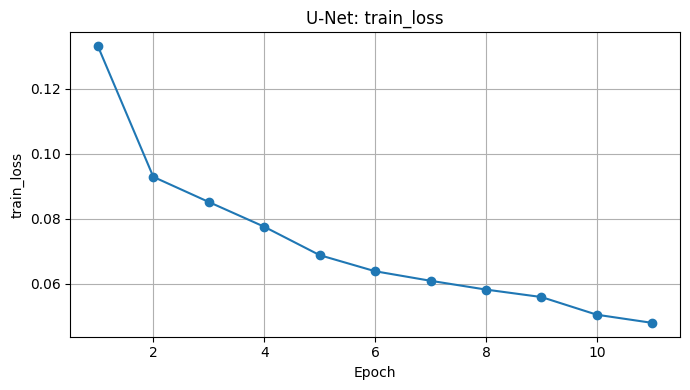

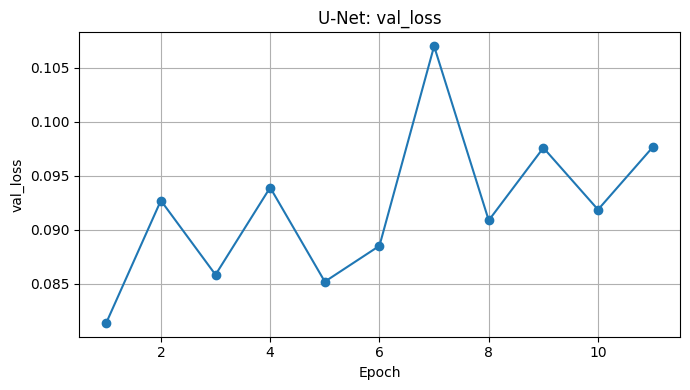

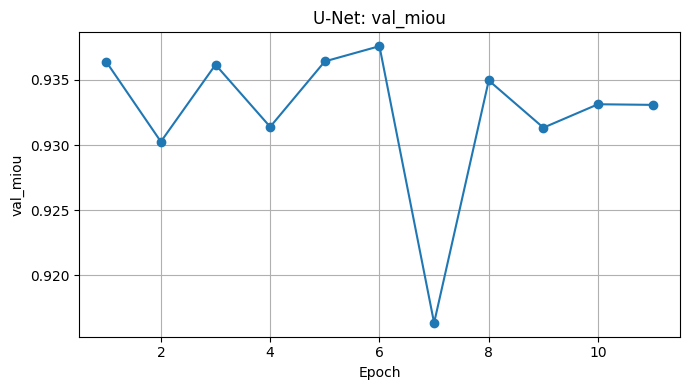

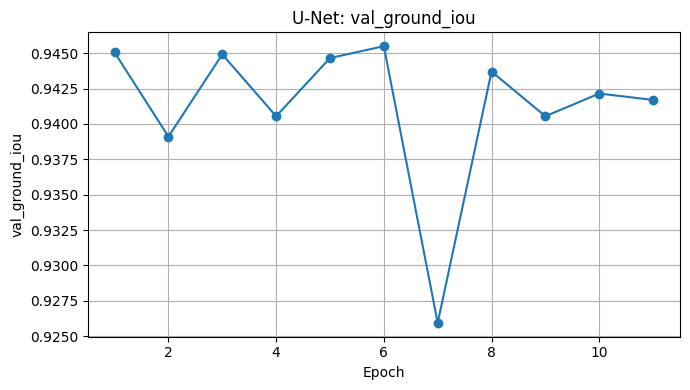

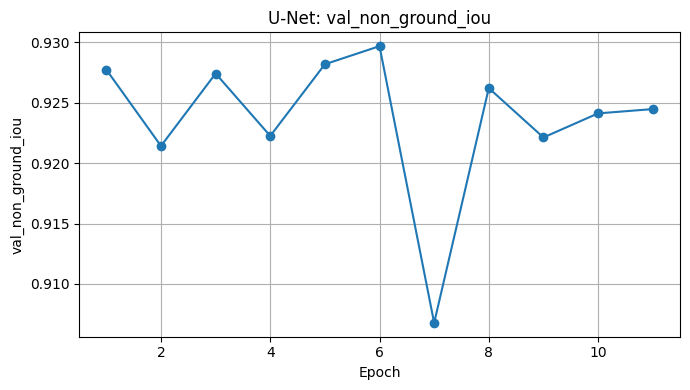

Evaluating U-Net test:   0%|          | 0/113 [00:00<?, ?it/s]


Test metrics:
                                                                        0
model                                                               U-Net
num_test_images                                                       899
best_epoch                                                              6
best_val_miou                                                    0.937593
non_ground_iou                                                   0.912608
ground_iou                                                       0.936638
miou                                                             0.924623
non_ground_dice                                                  0.954308
ground_dice                                                      0.967283
mean_dice                                                        0.960795
non_ground_precision                                             0.963707
ground_precision                                                 0.960574
mean_precision         

/tmp/ipykernel_2642/1833574328.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  .GradScaler(


Evaluating DeepLabV3+ baseline-val:   0%|          | 0/113 [00:00<?, ?it/s]

Baseline val mIoU before fine-tuning: 0.8132854180788638

Epoch 1/20


...

 epoch  train_loss  val_loss  val_non_ground_iou  val_ground_iou  val_miou  val_mean_dice  val_pixel_accuracy      lr
    10    0.053608  0.092823            0.922337        0.940401  0.931369       0.964442            0.965102 0.00005
No improvement. Patience: 4/5

Epoch 11/20


Training:   0%|          | 0/555 [00:00<?, ?it/s]

/tmp/ipykernel_2642/1833574328.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Evaluating DeepLabV3+ val:   0%|          | 0/113 [00:00<?, ?it/s]

 epoch  train_loss  val_loss  val_non_ground_iou  val_ground_iou  val_miou  val_mean_dice  val_pixel_accuracy      lr
    11    0.051376  0.095794            0.919945        0.939382  0.929664       0.963524            0.964271 0.00005
No improvement. Patience: 5/5
Early stopping triggered.


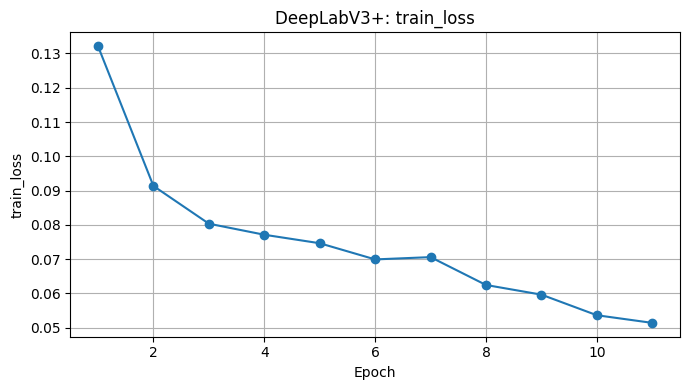

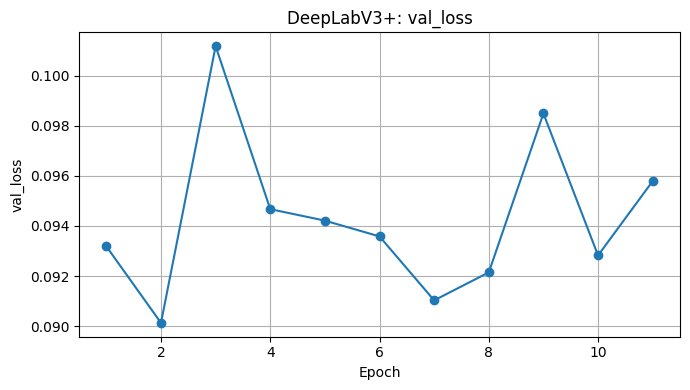

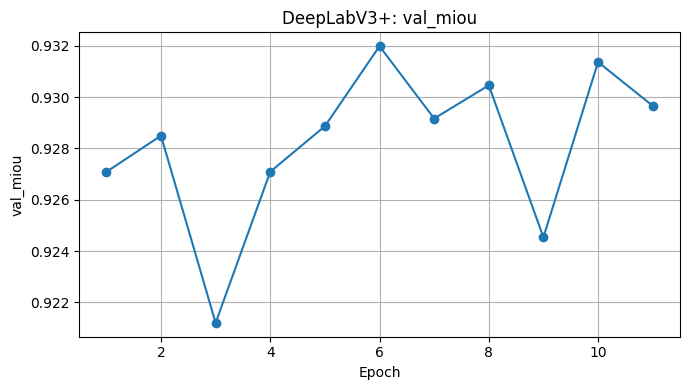

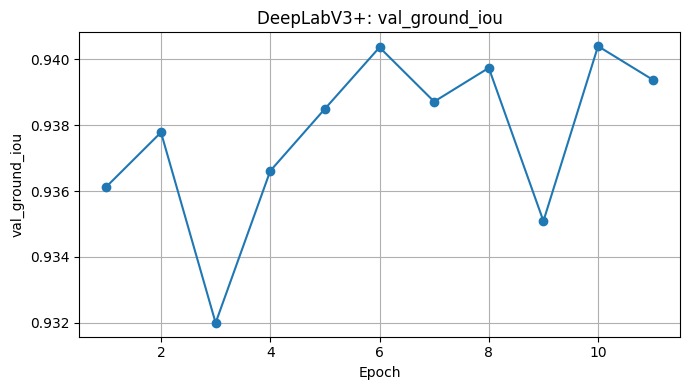

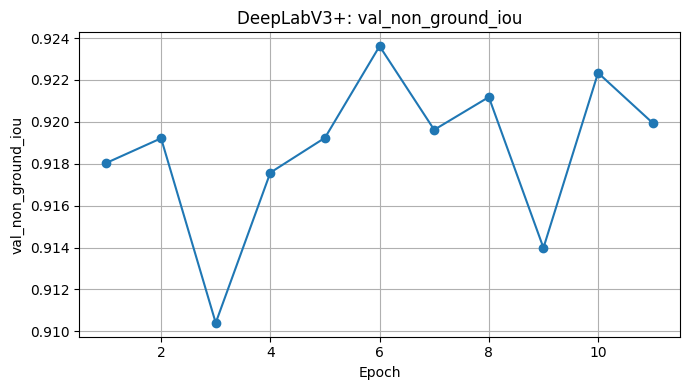

Evaluating DeepLabV3+ test:   0%|          | 0/113 [00:00<?, ?it/s]


Test metrics:
                                                                        0
model                                                          DeepLabV3+
num_test_images                                                       899
best_epoch                                                              6
best_val_miou                                                    0.931988
non_ground_iou                                                    0.91523
ground_iou                                                       0.937645
miou                                                             0.926438
non_ground_dice                                                  0.955739
ground_dice                                                      0.967819
mean_dice                                                        0.961779
non_ground_precision                                              0.95653
ground_precision                                                 0.967238
mean_precision         

/tmp/ipykernel_2642/1833574328.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  .GradScaler(


Evaluating SegFormer-B0 baseline-val:   0%|          | 0/113 [00:00<?, ?it/s]

Baseline val mIoU before fine-tuning: 0.8227429249037306

Epoch 1/20


...

 epoch  train_loss  val_loss  val_non_ground_iou  val_ground_iou  val_miou  val_mean_dice  val_pixel_accuracy      lr
     6    0.073255  0.092374            0.919618        0.938744  0.929181       0.963265            0.963984 0.00005
No improvement. Patience: 4/5

Epoch 7/20


Training:   0%|          | 0/555 [00:00<?, ?it/s]

/tmp/ipykernel_2642/1833574328.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe75f6a40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe75f6a40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 170

Evaluating SegFormer-B0 val:   0%|          | 0/113 [00:00<?, ?it/s]

 epoch  train_loss  val_loss  val_non_ground_iou  val_ground_iou  val_miou  val_mean_dice  val_pixel_accuracy      lr
     7    0.072077  0.093929            0.917864        0.937531  0.927697       0.962466            0.963212 0.00005
No improvement. Patience: 5/5
Early stopping triggered.


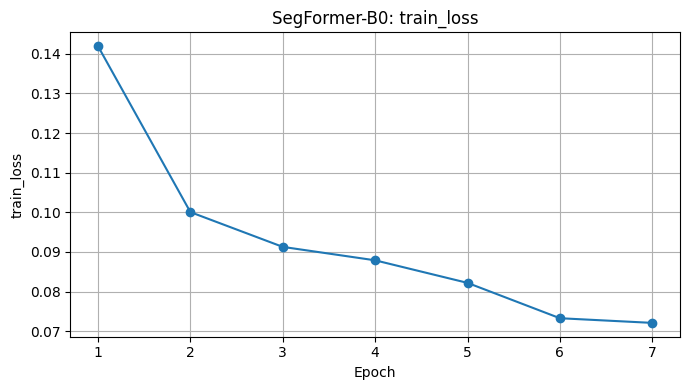

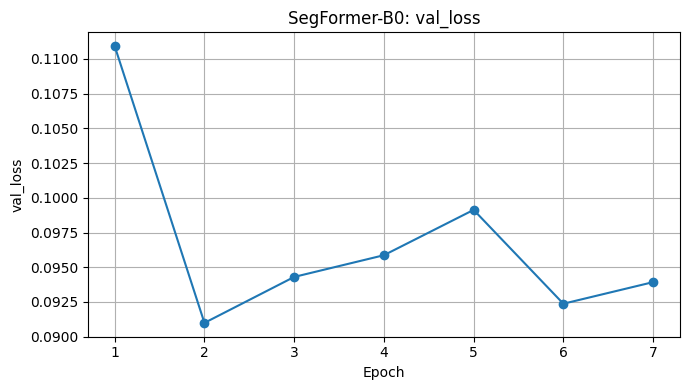

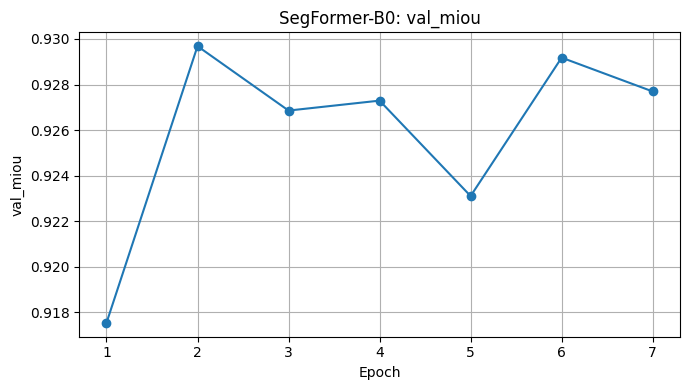

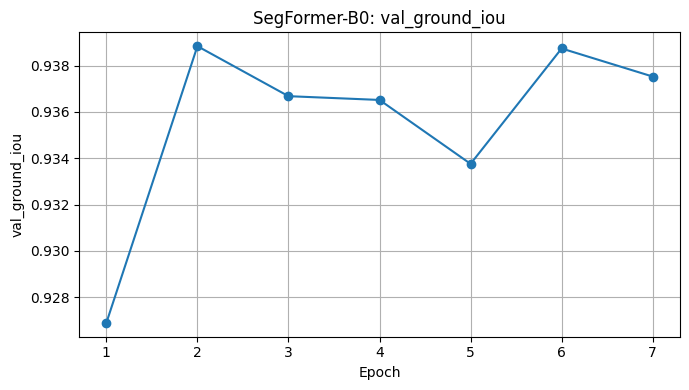

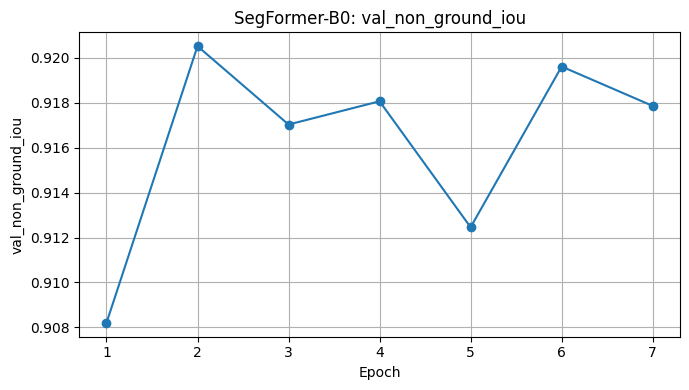

Evaluating SegFormer-B0 test:   0%|          | 0/113 [00:00<?, ?it/s]


Test metrics:
                                                                        0
model                                                        SegFormer-B0
num_test_images                                                       899
best_epoch                                                              2
best_val_miou                                                    0.929684
non_ground_iou                                                   0.913115
ground_iou                                                        0.93755
miou                                                             0.925332
non_ground_dice                                                  0.954584
ground_dice                                                      0.967768
mean_dice                                                        0.961176
non_ground_precision                                             0.969125
ground_precision                                                 0.957572
mean_precision         

/tmp/ipykernel_2642/1833574328.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  .GradScaler(


Evaluating ROD baseline-val:   0%|          | 0/900 [00:00<?, ?it/s]

Baseline val mIoU before fine-tuning: 0.7883686647758841

Epoch 1/20


...

 epoch  train_loss  val_loss  val_non_ground_iou  val_ground_iou  val_miou  val_mean_dice  val_pixel_accuracy       lr
    16    0.069594  0.078427            0.931049        0.947461  0.939255       0.968658            0.969265 0.000025
No improvement. Patience: 4/5

Epoch 17/20


Training:   0%|          | 0/4435 [00:00<?, ?it/s]

/tmp/ipykernel_2642/1833574328.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Evaluating ROD val:   0%|          | 0/900 [00:00<?, ?it/s]

 epoch  train_loss  val_loss  val_non_ground_iou  val_ground_iou  val_miou  val_mean_dice  val_pixel_accuracy       lr
    17    0.069345  0.077158            0.932855        0.948303  0.940579       0.969363            0.969913 0.000025
No improvement. Patience: 5/5
Early stopping triggered.


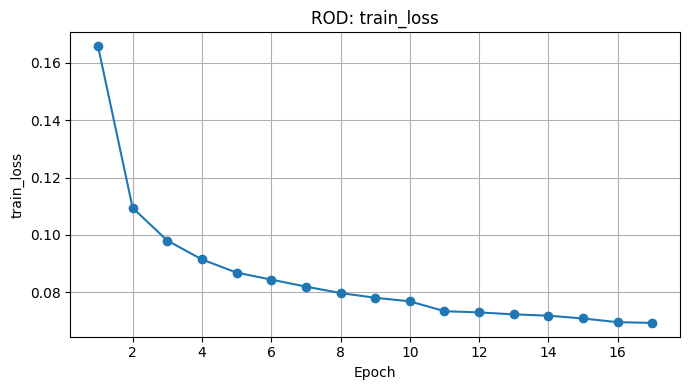

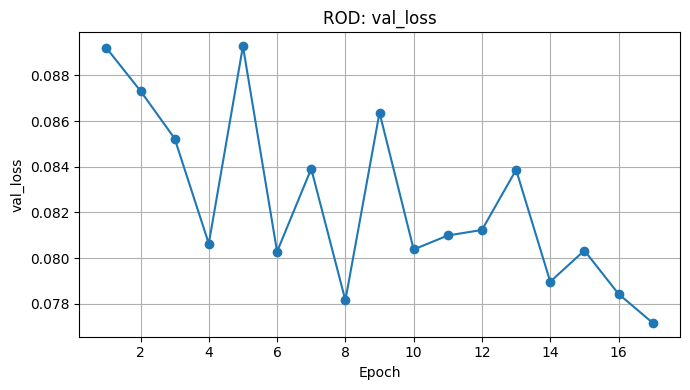

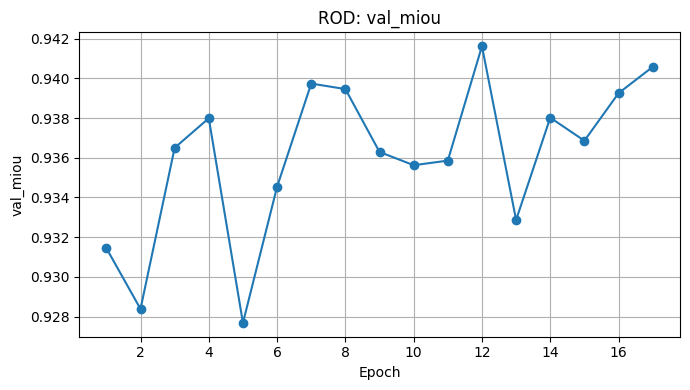

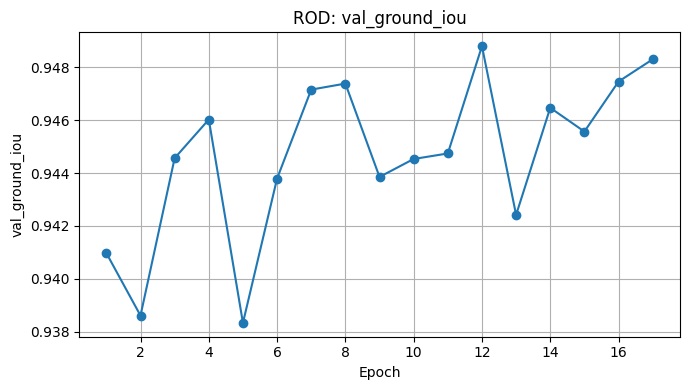

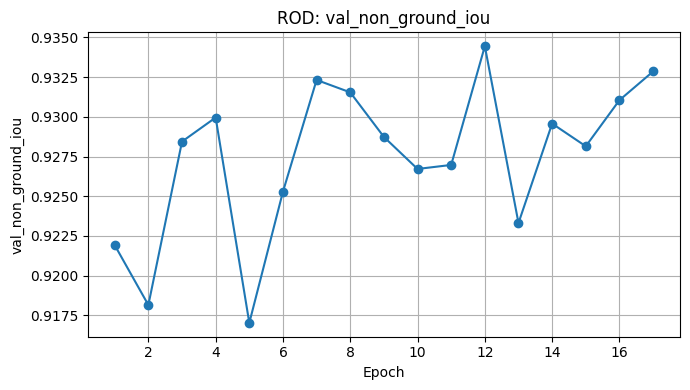

Evaluating ROD test:   0%|          | 0/899 [00:00<?, ?it/s]


Test metrics:
                                                                        0
model                                                                 ROD
num_test_images                                                       899
best_epoch                                                             12
best_val_miou                                                    0.941624
non_ground_iou                                                   0.926185
ground_iou                                                       0.944805
miou                                                             0.935495
non_ground_dice                                                  0.961678
ground_dice                                                      0.971619
mean_dice                                                        0.966649
non_ground_precision                                             0.952369
ground_precision                                                 0.978704
mean_precision         

,model,num_test_images,best_epoch,best_val_miou,non_ground_iou,ground_iou,miou,non_ground_dice,ground_dice,mean_dice,...,mean_precision,non_ground_recall,ground_recall,mean_recall,pixel_accuracy,valid_pixels,loss,mean_inference_time_ms,fps,checkpoint_path
0,U-Net,899,6,0.937593,0.912608,0.936638,0.924623,0.954308,0.967283,0.960795,...,0.962141,0.945090,0.974086,0.959588,0.961869,156405114,0.097474,19.689599,50.788235,/content/drive/MyDrive/IRP/04_target_domain_fi...
1,DeepLabV3+,899,6,0.931988,0.915230,0.937645,0.926438,0.955739,0.967819,0.961779,...,0.961884,0.954949,0.968402,0.961676,0.962734,156405114,0.092286,10.607984,94.268615,/content/drive/MyDrive/IRP/04_target_domain_fi...
2,SegFormer-B0,899,2,0.929684,0.913115,0.937550,0.925332,0.954584,0.967768,0.961176,...,0.963349,0.940473,0.978185,0.959329,0.962296,156405114,0.093385,16.423036,60.890083,/content/drive/MyDrive/IRP/04_target_domain_fi...
3,ROD,899,12,0.941624,0.926185,0.944805,0.935495,0.961678,0.971619,0.966649,...,0.965537,0.971172,0.964636,0.967904,0.967389,97753661,0.080846,80.034124,12.494670,/content/drive/MyDrive/IRP/04_target_domain_fi...


In [17]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device,
)

all_results = []

for model_name in (
    MODEL_DISPLAY_ORDER
):
    checkpoint_path = (
        CHECKPOINTS[
            model_name
        ]
    )

    result = finetune_model(
        model_name,
        checkpoint_path,
        device,
    )

    all_results.append(
        result
    )

results_df = pd.DataFrame(
    all_results
)

results_csv = (
    RESULTS_ROOT
    / "rellis3d_finetune_results.csv"
)

results_df.to_csv(
    results_csv,
    index=False,
)

print(
    "\nSaved results to:",
    results_csv,
)

display(
    results_df
)

## 10. Compare Experiment 2 and Experiment 3

In [18]:
# This cell is optional. It searches common locations for the CSV generated by your
# RUGD -> RELLIS-3D direct testing notebook.
exp2_csv = None
for candidate in EXP2_CSV_CANDIDATES:
    if candidate.exists():
        exp2_csv = candidate
        break

if exp2_csv is None:
    print('No Experiment 2 CSV found in the common paths below:')
    for candidate in EXP2_CSV_CANDIDATES:
        print(' ', candidate)
    print('\nYou can manually set exp2_csv = Path("...") and rerun this cell.')
else:
    print('Using Experiment 2 CSV:', exp2_csv)
    exp2 = pd.read_csv(exp2_csv)
    exp3 = pd.read_csv(results_csv)

    exp2 = exp2.copy()
    exp3 = exp3.copy()
    exp2['experiment'] = 'Exp2_RUGD_to_RELLIS_zero_shot'
    exp3['experiment'] = 'Exp3_RUGD_to_RELLIS_finetune'

    common_cols = [
        'experiment', 'model', 'num_test_images',
        'non_ground_iou', 'ground_iou', 'miou',
        'mean_dice', 'mean_precision', 'mean_recall',
        'pixel_accuracy', 'mean_inference_time_ms', 'fps'
    ]
    common_cols = [c for c in common_cols if c in exp2.columns and c in exp3.columns or c in ['experiment']]

    combined = pd.concat([
        exp2[[c for c in common_cols if c in exp2.columns]],
        exp3[[c for c in common_cols if c in exp3.columns]],
    ], ignore_index=True)

    comparison_csv = RESULTS_ROOT / 'exp2_vs_exp3_comparison.csv'
    combined.to_csv(comparison_csv, index=False)

    display(combined)

    # Improvement table.
    metric_cols = ['non_ground_iou', 'ground_iou', 'miou', 'mean_dice', 'pixel_accuracy']
    metric_cols = [c for c in metric_cols if c in exp2.columns and c in exp3.columns]

    zero = exp2.set_index('model')
    fine = exp3.set_index('model')
    rows = []
    for model in sorted(set(zero.index).intersection(fine.index)):
        row = {'model': model}
        for metric in metric_cols:
            row[f'{metric}_exp2'] = zero.loc[model, metric]
            row[f'{metric}_exp3'] = fine.loc[model, metric]
            row[f'{metric}_delta'] = fine.loc[model, metric] - zero.loc[model, metric]
        rows.append(row)

    improvement = pd.DataFrame(rows)
    improvement_csv = RESULTS_ROOT / 'exp2_to_exp3_improvement.csv'
    improvement.to_csv(improvement_csv, index=False)

    print('Saved comparison:', comparison_csv)
    print('Saved improvement:', improvement_csv)
    display(improvement)

Using Experiment 2 CSV: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_rellis3d/model_summary.csv


,experiment,model,num_test_images,non_ground_iou,ground_iou,miou,mean_dice,mean_precision,mean_recall,pixel_accuracy,mean_inference_time_ms,fps
0,Exp2_RUGD_to_RELLIS_zero_shot,U-Net,899,0.809507,0.854322,0.831915,0.908083,0.906764,0.909681,0.910024,2.559584,390.688559
1,Exp2_RUGD_to_RELLIS_zero_shot,DeepLabV3+,899,0.759685,0.837822,0.798754,0.887594,0.901146,0.880772,0.892788,1.917448,521.526664
2,Exp2_RUGD_to_RELLIS_zero_shot,SegFormer-B0,899,0.804442,0.854760,0.829601,0.906659,0.907175,0.906170,0.909081,2.801095,357.003228
3,Exp2_RUGD_to_RELLIS_zero_shot,ROD,899,0.836005,0.890719,0.863362,0.926440,0.940911,0.918851,0.929817,80.403583,12.437257
4,Exp3_RUGD_to_RELLIS_finetune,U-Net,899,0.912608,0.936638,0.924623,0.960795,0.962141,0.959588,0.961869,19.689599,50.788235
5,Exp3_RUGD_to_RELLIS_finetune,DeepLabV3+,899,0.915230,0.937645,0.926438,0.961779,0.961884,0.961676,0.962734,10.607984,94.268615
6,Exp3_RUGD_to_RELLIS_finetune,SegFormer-B0,899,0.913115,0.937550,0.925332,0.961176,0.963349,0.959329,0.962296,16.423036,60.890083
7,Exp3_RUGD_to_RELLIS_finetune,ROD,899,0.926185,0.944805,0.935495,0.966649,0.965537,0.967904,0.967389,80.034124,12.494670


Saved comparison: /content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/exp2_vs_exp3_comparison.csv
Saved improvement: /content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d/exp2_to_exp3_improvement.csv


,model,non_ground_iou_exp2,non_ground_iou_exp3,non_ground_iou_delta,ground_iou_exp2,ground_iou_exp3,ground_iou_delta,miou_exp2,miou_exp3,miou_delta,mean_dice_exp2,mean_dice_exp3,mean_dice_delta,pixel_accuracy_exp2,pixel_accuracy_exp3,pixel_accuracy_delta
0,DeepLabV3+,0.759685,0.915230,0.155545,0.837822,0.937645,0.099823,0.798754,0.926438,0.127684,0.887594,0.961779,0.074185,0.892788,0.962734,0.069946
1,ROD,0.836005,0.926185,0.090180,0.890719,0.944805,0.054086,0.863362,0.935495,0.072133,0.926440,0.966649,0.040209,0.929817,0.967389,0.037572
2,SegFormer-B0,0.804442,0.913115,0.108673,0.854760,0.937550,0.082789,0.829601,0.925332,0.095731,0.906659,0.961176,0.054518,0.909081,0.962296,0.053215
3,U-Net,0.809507,0.912608,0.103101,0.854322,0.936638,0.082316,0.831915,0.924623,0.092708,0.908083,0.960795,0.052712,0.910024,0.961869,0.051845


## 11. Top-5, Bottom-5, and common failure visualisation

For each fine-tuned model, Top-5 and Bottom-5 cases are displayed in five columns:

`RGB | GT ground | Prediction | Prediction overlay | Errors`

The five common failure cases are ranked by average per-image mIoU across all four fine-tuned models and displayed in six columns:

`RGB | Ground Truth | U-Net | DeepLabV3+ | SegFormer-B0 | ROD`

In [21]:
def load_finetuned_model_for_visualization(
    model_name,
    device,
):
    model_out_dir = (
        RESULTS_ROOT
        / model_safe_name(
            model_name
        )
    )

    ckpt_path = (
        model_out_dir
        / "best_rellis3d_finetuned.pth"
    )

    checkpoint = (
        load_checkpoint_file(
            ckpt_path
        )
    )

    model = build_model(
        model_name,
        checkpoint=checkpoint,
    )

    model = (
        load_checkpoint_into_model(
            model,
            checkpoint,
            strict=True,
        )
    )

    return (
        model
        .to(
            device
        )
        .eval()
    )


def dataset_for_model(
    model_name
):
    if model_name == "ROD":
        return rod_test_dataset

    return test_dataset


def find_test_index(
    model_name,
    image_path,
):
    dataset = (
        dataset_for_model(
            model_name
        )
    )

    for index, (
        candidate_image,
        candidate_mask,
    ) in enumerate(
        dataset.pairs
    ):
        if (
            str(
                candidate_image
            )
            == str(
                image_path
            )
        ):
            return index

    raise KeyError(
        f"Image not found in "
        f"{model_name} test dataset: "
        f"{image_path}"
    )


@torch.inference_mode()
def predict_test_index(
    model_name,
    model,
    index,
):
    dataset = dataset_for_model(
        model_name
    )

    sample = dataset[index]

    image = (
        sample["image"]
        .unsqueeze(0)
        .to(device)
        .float()
    )

    output = model(image)

    # --------------------------------------------------
    # ROD: prediction is in padded 512x512 coordinates
    # --------------------------------------------------
    if model_name == "ROD":
        logits = extract_logits(
            output,
            target_size=INPUT_SIZE,
        )

        padded_prediction = (
            torch.argmax(
                logits,
                dim=1,
            )[0]
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

        # Read ORIGINAL image to recover its aspect ratio.
        original_image = Image.open(
            sample["image_path"]
        ).convert("RGB")

        original_w, original_h = (
            original_image.size
        )

        # Reproduce exactly the padding geometry used by ROD.
        scale = (
            INPUT_SIZE[0]
            / max(
                original_h,
                original_w,
            )
        )

        new_h = int(
            round(
                original_h * scale
            )
        )

        new_w = int(
            round(
                original_w * scale
            )
        )

        top = (
            INPUT_SIZE[0]
            - new_h
        ) // 2

        left = (
            INPUT_SIZE[1]
            - new_w
        ) // 2

        # Remove padding.
        cropped_prediction = (
            padded_prediction[
                top:top + new_h,
                left:left + new_w,
            ]
        )

        # Restore prediction to original image resolution.
        prediction = np.array(
            Image.fromarray(
                cropped_prediction
            ).resize(
                (
                    original_w,
                    original_h,
                ),
                resample=(
                    Image.Resampling.NEAREST
                ),
            ),
            dtype=np.uint8,
        )

    # --------------------------------------------------
    # U-Net / DeepLabV3+ / SegFormer
    # --------------------------------------------------
    else:
        mask_512 = (
            sample["mask"]
            .cpu()
            .numpy()
        )

        logits = extract_logits(
            output,
            target_size=(
                mask_512.shape
            ),
        )

        prediction_512 = (
            torch.argmax(
                logits,
                dim=1,
            )[0]
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

        original_image = Image.open(
            sample["image_path"]
        ).convert("RGB")

        original_w, original_h = (
            original_image.size
        )

        prediction = np.array(
            Image.fromarray(
                prediction_512
            ).resize(
                (
                    original_w,
                    original_h,
                ),
                resample=(
                    Image.Resampling.NEAREST
                ),
            ),
            dtype=np.uint8,
        )

    # --------------------------------------------------
    # Always use ORIGINAL RGB and GT for visualisation
    # --------------------------------------------------
    rgb = np.array(
        Image.open(
            sample["image_path"]
        ).convert("RGB")
    ).astype(
        np.float32
    ) / 255.0

    mask = np.array(
        Image.open(
            sample["mask_path"]
        ).convert("L"),
        dtype=np.uint8,
    )

    return (
        sample,
        rgb,
        mask,
        prediction,
    )

def make_error_map(
    mask,
    prediction,
):
    valid = (
        mask
        != IGNORE_INDEX
    )

    false_ground = (
        valid
        & (
            mask
            == NON_GROUND_CLASS
        )
        & (
            prediction
            == GROUND_CLASS
        )
    )

    false_non_ground = (
        valid
        & (
            mask
            == GROUND_CLASS
        )
        & (
            prediction
            == NON_GROUND_CLASS
        )
    )

    error_map = np.zeros(
        (
            mask.shape[0],
            mask.shape[1],
            3,
        ),
        dtype=np.uint8,
    )

    error_map[
        false_ground
    ] = [
        255,
        0,
        0,
    ]

    error_map[
        false_non_ground
    ] = [
        0,
        100,
        255,
    ]

    return (
        error_map
    )


def show_prediction_case(
    model_name,
    model,
    index,
    title_text,
    save_path=None,
):
    (
        sample,
        rgb,
        mask,
        prediction,
    ) = predict_test_index(
        model_name,
        model,
        index,
    )

    error_map = (
        make_error_map(
            mask,
            prediction,
        )
    )

    figure, axes = (
        plt.subplots(
            1,
            5,
            figsize=(
                23,
                5,
            ),
        )
    )

    axes[0].imshow(
        rgb
    )

    axes[0].set_title(
        "RGB"
    )

    axes[1].imshow(
        mask
        == GROUND_CLASS,
        cmap="gray",
    )

    axes[1].set_title(
        "GT ground"
    )

    axes[2].imshow(
        prediction
        == GROUND_CLASS,
        cmap="gray",
    )

    axes[2].set_title(
        f"{model_name} "
        f"prediction"
    )

    axes[3].imshow(
        rgb
    )

    axes[3].imshow(
        prediction
        == GROUND_CLASS,
        alpha=0.4,
        cmap="Greens",
    )

    axes[3].set_title(
        "Prediction overlay"
    )

    axes[4].imshow(
        error_map
    )

    axes[4].set_title(
        "Errors\n"
        "red=false ground\n"
        "blue=false non-ground"
    )

    for axis in axes:
        axis.axis(
            "off"
        )

    figure.suptitle(
        title_text
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.90,
        ]
    )

    if save_path is not None:
        save_path = Path(
            save_path
        )

        save_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        figure.savefig(
            save_path,
            dpi=180,
            bbox_inches="tight",
        )

    plt.show()

    plt.close(
        figure
    )


RANKED_CASES_ROOT = (
    RESULTS_ROOT
    / "ranked_cases"
)

RANKED_CASES_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


for model_name in (
    MODEL_DISPLAY_ORDER
):
    model_out_dir = (
        RESULTS_ROOT
        / model_safe_name(
            model_name
        )
    )

    per_image_path = (
        model_out_dir
        / "rellis3d_test_per_image_metrics.csv"
    )

    dataframe = pd.read_csv(
        per_image_path
    )

    valid_df = (
        dataframe
        .dropna(
            subset=[
                "miou"
            ]
        )
    )

    top_five = (
        valid_df
        .sort_values(
            "miou",
            ascending=False,
        )
        .head(
            5
        )
    )

    bottom_five = (
        valid_df
        .sort_values(
            "miou",
            ascending=True,
        )
        .head(
            5
        )
    )

    top_five.to_csv(
        model_out_dir
        / "top5_cases.csv",
        index=False,
    )

    bottom_five.to_csv(
        model_out_dir
        / "bottom5_cases.csv",
        index=False,
    )

    model = (
        load_finetuned_model_for_visualization(
            model_name,
            device,
        )
    )

    for (
        group_name,
        selected,
    ) in [
        (
            "Top-5 Best",
            top_five,
        ),
        (
            "Bottom-5 Worst",
            bottom_five,
        ),
    ]:
        print(
            "\n"
            + "=" * 90
        )

        print(
            f"{model_name}: "
            f"{group_name}"
        )

        print(
            "=" * 90
        )

        display(
            selected[
                [
                    "non_ground_iou",
                    "ground_iou",
                    "miou",
                    "pixel_accuracy",
                    "image_path",
                ]
            ].reset_index(
                drop=True
            )
        )

        for (
            rank,
            (_, row),
        ) in enumerate(
            selected.iterrows(),
            start=1,
        ):
            index = (
                find_test_index(
                    model_name,
                    row[
                        "image_path"
                    ],
                )
            )

            safe_group = (
                group_name.lower()
                .replace(
                    " ",
                    "_",
                )
                .replace(
                    "-",
                    "",
                )
            )

            save_path = (
                RANKED_CASES_ROOT
                / model_safe_name(
                    model_name
                )
                / safe_group
                / (
                    f"{rank:02d}_"
                    f"{Path(row['image_path']).stem}.png"
                )
            )

            show_prediction_case(
                model_name=(
                    model_name
                ),
                model=model,
                index=index,
                title_text=(
                    f"{model_name} | "
                    f"{group_name} "
                    f"#{rank} | "
                    f"mIoU="
                    f"{row['miou']:.4f}"
                ),
                save_path=(
                    save_path
                ),
            )


# --------------------------------------------------
# Common failure cases
# --------------------------------------------------
combined = None

for model_name in (
    MODEL_DISPLAY_ORDER
):
    dataframe = pd.read_csv(
        RESULTS_ROOT
        / model_safe_name(
            model_name
        )
        / "rellis3d_test_per_image_metrics.csv"
    )

    subset = (
        dataframe[
            [
                "image_path",
                "mask_path",
                "miou",
            ]
        ]
        .rename(
            columns={
                "miou": (
                    model_name
                )
            }
        )
    )

    if combined is None:
        combined = subset

    else:
        combined = (
            combined.merge(
                subset,
                on=[
                    "image_path",
                    "mask_path",
                ],
                how="inner",
            )
        )


combined[
    "average_miou"
] = (
    combined[
        MODEL_DISPLAY_ORDER
    ]
    .mean(
        axis=1,
        skipna=False,
    )
)


common_worst_10 = (
    combined
    .dropna(
        subset=[
            "average_miou"
        ]
    )
    .sort_values(
        "average_miou",
        ascending=True,
    )
    .head(
        10
    )
    .reset_index(
        drop=True
    )
)

common_worst_5 = (
    common_worst_10
    .head(
        5
    )
    .copy()
)


common_worst_10.to_csv(
    RESULTS_ROOT
    / "common_worst_finetuned_rellis3d_cases.csv",
    index=False,
)


print(
    "\n===== Common Worst "
    "RELLIS-3D Cases ====="
)

display(
    common_worst_10
)


fine_tuned_models = {
    model_name: (
        load_finetuned_model_for_visualization(
            model_name,
            device,
        )
    )
    for model_name
    in MODEL_DISPLAY_ORDER
}


def original_rgb(
    image_path
):
    return np.array(
        Image.open(
            image_path
        ).convert(
            "RGB"
        )
    )


def original_mask(
    mask_path
):
    return np.array(
        Image.open(
            mask_path
        ).convert(
            "L"
        ),
        dtype=np.uint8,
    )


@torch.inference_mode()
def predict_original_resolution(
    model_name,
    model,
    image_path,
):
    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )

    original_w, original_h = (
        image.size
    )

    if model_name == "ROD":
        image_np = np.array(
            image,
            dtype=np.uint8,
        )

        dummy_mask = np.zeros(
            image_np.shape[
                :2
            ],
            dtype=np.uint8,
        )

        (
            padded_image,
            _,
        ) = rod_resize_pad_pair(
            image_np,
            dummy_mask,
            size=INPUT_SIZE[0],
        )

        padded_image = (
            padded_image.astype(
                np.float32
            )
            - ROD_PIXEL_MEAN
        ) / ROD_PIXEL_STD

        tensor = (
            torch.from_numpy(
                padded_image
            )
            .permute(
                2,
                0,
                1,
            )
            .unsqueeze(
                0
            )
            .to(
                device
            )
            .float()
        )

    else:
        resized = TF.resize(
            image,
            INPUT_SIZE,
            interpolation=(
                InterpolationMode.BILINEAR
            ),
            antialias=True,
        )

        tensor = TF.to_tensor(
            resized
        )

        tensor = TF.normalize(
            tensor,
            IMAGENET_MEAN,
            IMAGENET_STD,
        )

        tensor = (
            tensor
            .unsqueeze(
                0
            )
            .to(
                device
            )
            .float()
        )

    logits = (
        extract_logits(
            model(
                tensor
            ),
            target_size=(
                INPUT_SIZE
            ),
        )
    )

    prediction = (
        torch.argmax(
            logits,
            dim=1,
        )[0]
        .cpu()
        .numpy()
        .astype(
            np.uint8
        )
    )

    prediction = np.array(
        Image.fromarray(
            prediction
        ).resize(
            (
                original_w,
                original_h,
            ),
            resample=(
                Image.Resampling.NEAREST
            ),
        ),
        dtype=np.uint8,
    )

    return (
        prediction
    )


def ground_overlay(
    rgb_uint8,
    prediction,
    alpha=0.42,
):
    rgb = (
        rgb_uint8.astype(
            np.float32
        )
        / 255.0
    )

    overlay = rgb.copy()

    region = (
        prediction
        == GROUND_CLASS
    )

    green = np.zeros_like(
        rgb
    )

    green[
        ...,
        1
    ] = 1.0

    overlay[
        region
    ] = (
        (1.0 - alpha)
        * rgb[
            region
        ]
        + alpha
        * green[
            region
        ]
    )

    return np.clip(
        overlay,
        0,
        1,
    )


COMMON_FAILURE_DIR = (
    RESULTS_ROOT
    / "common_failure_cases"
)

COMMON_FAILURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


for (
    rank,
    (_, row),
) in enumerate(
    common_worst_5.iterrows(),
    start=1,
):
    rgb = original_rgb(
        row[
            "image_path"
        ]
    )

    gt = original_mask(
        row[
            "mask_path"
        ]
    )

    figure, axes = (
        plt.subplots(
            1,
            6,
            figsize=(
                28,
                5,
            ),
        )
    )

    axes[0].imshow(
        rgb
    )

    axes[0].set_title(
        "RGB"
    )

    axes[1].imshow(
        gt
        == GROUND_CLASS,
        cmap="gray",
    )

    axes[1].set_title(
        "Ground Truth"
    )

    for (
        column,
        model_name,
    ) in enumerate(
        MODEL_DISPLAY_ORDER,
        start=2,
    ):
        prediction = (
            predict_original_resolution(
                model_name,
                fine_tuned_models[
                    model_name
                ],
                row[
                    "image_path"
                ],
            )
        )

        overlay = ground_overlay(
            rgb,
            prediction,
        )

        axes[
            column
        ].imshow(
            overlay
        )

        axes[
            column
        ].set_title(
            f"{model_name}\n"
            f"mIoU="
            f"{row[model_name]:.3f}"
        )

    for axis in axes:
        axis.axis(
            "off"
        )

    figure.suptitle(
        f"Common Failure "
        f"#{rank} | "
        f"average mIoU="
        f"{row['average_miou']:.4f}"
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.90,
        ]
    )

    save_path = (
        COMMON_FAILURE_DIR
        / (
            f"common_failure_"
            f"{rank:02d}_"
            f"{Path(row['image_path']).stem}.png"
        )
    )

    figure.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        save_path,
    )

    plt.show()

    plt.close(
        figure
    )


print(
    "\nAll results saved directly to:"
)

print(
    RESULTS_ROOT
)

Output hidden; open in https://colab.research.google.com to view.

## 12. Reporting note

This notebook now evaluates four target-domain adaptation runs:

- U-Net
- DeepLabV3+
- SegFormer-B0
- ROD

All four models use **Cross-Entropy only** during RELLIS-3D fine-tuning. Dice is retained only as an evaluation metric.

The qualitative analysis contains:
- Top-5 cases for each model;
- Bottom-5 cases for each model;
- five shared failure cases ranked by average per-image mIoU across all four models.

All outputs are written directly to:

`/content/drive/MyDrive/IRP/04_target_domain_finetuning/rellis3d`